<center><h1>Satish_Manvika_HW2</h1></center>
<br>
<br>

Name: Manvika Satish
<br>
Github Username: manvsatish
<br>
USC ID: 5582061880

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

sns.set_theme(style="whitegrid")

Get the Cycle Power Plant Data Set

In [3]:
data = pd.read_excel("../data/CCPP/Folds5x2_pp.xlsx", sheet_name=0)
data.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Exploring the data

#### i. rows and columns

In [5]:
num_rows, num_cols = data.shape #display num of rows and cols
print("Number of Rows:", num_rows)
print("Number of Columns:", num_cols)

print("\nDataset Information:") 
data.info()#info about each col
print("\nMissing Values:") 
print(data.isnull().sum()) #check for missing vals

Number of Rows: 9568
Number of Columns: 5

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB

Missing Values:
AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64


**How many rows are in this data set? How many columns? What do the rows and columns represent?**
The dataset contains 9568 rows and 5 columns. Each row represents one hourly observation collected while the powerplant was operating at full load. The columns represent Ambient Temperature (AT), Exhaust Vacuum (V), Ambient Pressure (AP), Relative Humidity (RH), and Net hourly electrical energy output (PE). AT, V, AP, and RH are independent variables used to predict PE, which is the dependent variable. The dataset doesn't contain any missing values. 

#### ii. pairwise scatterplots of all the variables

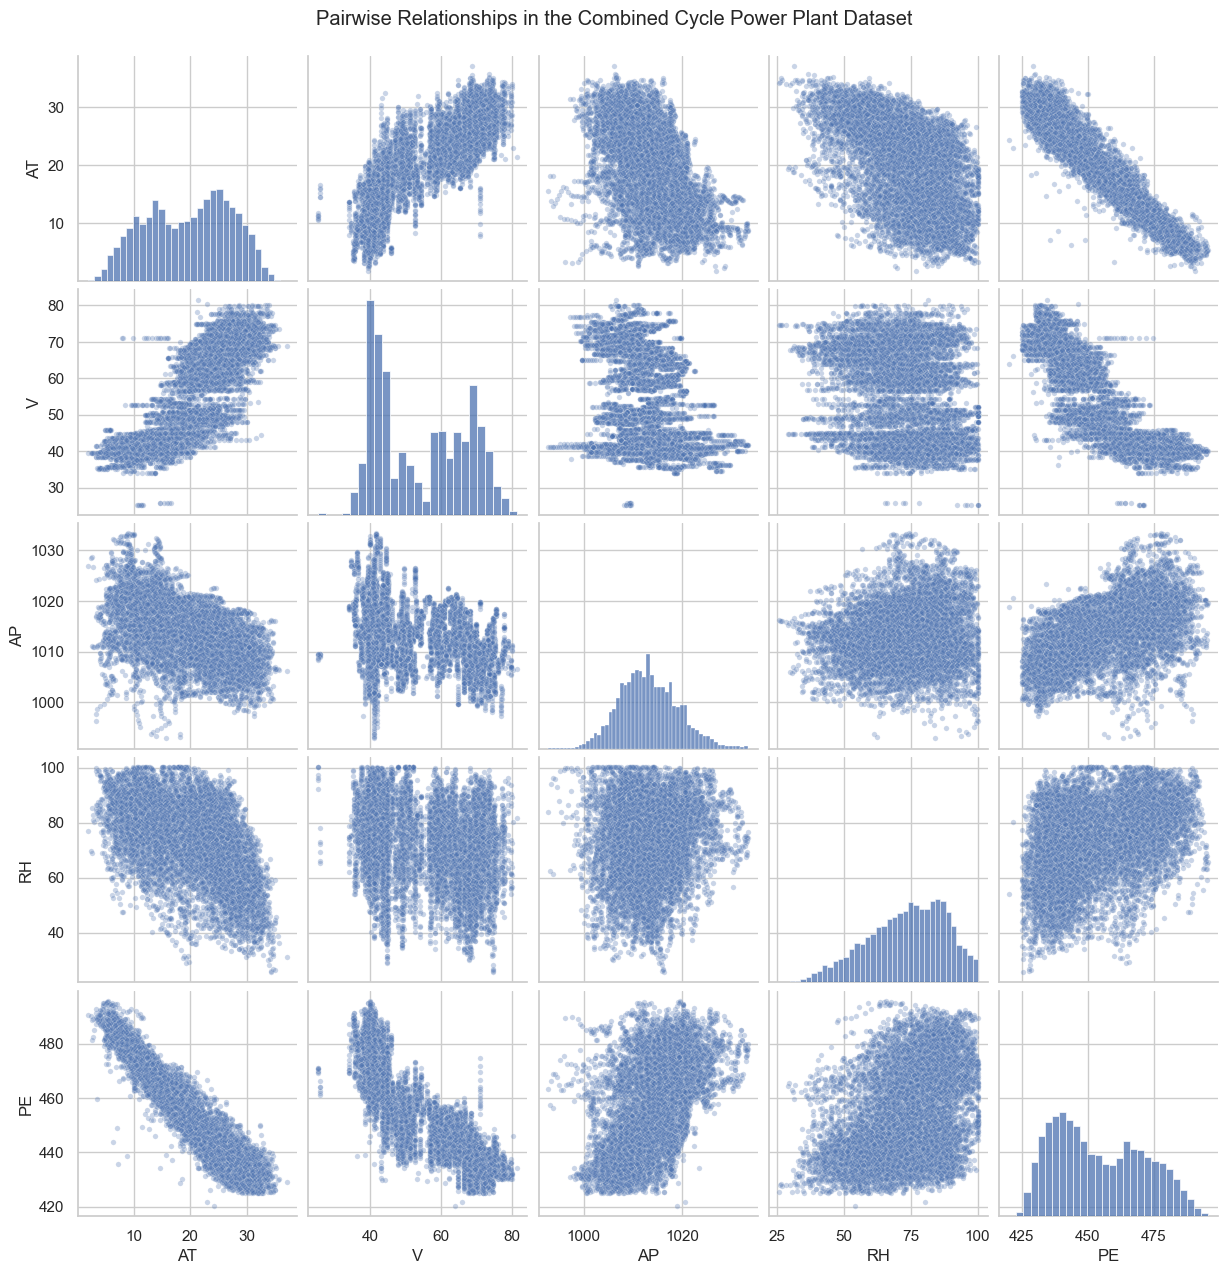

In [7]:
pair_plot = sns.pairplot(data, diag_kind="hist", plot_kws={"alpha": 0.30, "s": 15})
pair_plot.fig.suptitle("Pairwise Relationships in the Combined Cycle Power Plant Dataset", y = 1.02)

plt.show()

**Make pairwise scatterplots of all the varianbles in the data set including the predictors (independent variables) with the dependent variable. Describe your findings.**
The pairwise scatterplots show several noticeable relationships. First, AT and PE have a strong negative relationship, so as the ambient temperature increases, electrical energy output generally decreases. This relationship looks to be slightly curved rather than perfectly linear. Next, V and PE also have a negative relationship. Higher exhaust vacuum values generally correspond to lower electrical energy output. The observations form several clusters or bands, which could represent different operating conditions. Additionally, AP and PE have a weaker positive relationship, meaning that higher ambient pressure is generally associated with higher electrical energy output, but the observations are widely dispersed; there isn't really a clear pattern. Next, RH and PE have a relatively weak positive relationship, so the large amount of variation suggests that relative humidity alone is not a particularly strong predictor of electrical output. Some predictors are also associated with each other. AT and V have a positive, somewhat nonlinear relationship, while AT appears negatively associated with both AP and RH.

A few observations appear to be separated from the main concentration of points. However, these plots by themselves don't provide enough evidence to conclude that those observations are errors. Overall, AT seems to have the strongest individual relationship with PE. Some relationships also appear nonlinear.

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [12]:
summary_table = pd.DataFrame({"Mean": data.mean(), "Median": data.median(), "Minimum": data.min(), "Maximum": data.max(), "Range": data.max() - data.min(), "First Quartile": data.quantile(0.25), "Third Quartile": data.quantile(0.75), "Interquartile Range": (data.quantile(0.75) - data.quantile(0.25))})
summary_table.round(2)

,Mean,Median,Minimum,Maximum,Range,First Quartile,Third Quartile,Interquartile Range
AT,19.65,20.34,1.81,37.11,35.30,13.51,25.72,12.21
V,54.31,52.08,25.36,81.56,56.20,41.74,66.54,24.80
AP,1013.26,1012.94,992.89,1033.30,40.41,1009.10,1017.26,8.16
RH,73.31,74.97,25.56,100.16,74.60,63.33,84.83,21.50
PE,454.37,451.55,420.26,495.76,75.50,439.75,468.43,28.68


**What are the mean, the median, range, first and third quartiles, and interquartile ranges of each of the variables in the dataset? Summarize them in a table.**
The means and medians are reasonably close for most variables, but V and PE show slightly larger differences. Among the predictors, RH has the largest overall range, and AP has the smallest IQR. The middle 50% of PE values fall between about 439.75 and 468.43, giving PE an IQR of approximately 28.68.

### (c) Simple Linear Regression

In [13]:
predictors = ["AT", "V", "AP", "RH"] #predictor vars used in the lin reg models
simple_models = {}
simple_results = []

for predictor in predictors:
    X = sm.add_constant(data[[predictor]]) # add intercept to selected predictor
    # fit a model that predicts pe using the current predictor 
    model = sm.OLS(
        data["PE"],
        X
    ).fit()
    simple_models[predictor] = model #save fitted model

    simple_results.append({
        "Predictor": predictor,
        "Intercept": model.params["const"],
        "Coefficient": model.params[predictor],
        "P-value": model.pvalues[predictor],
        "R-squared": model.rsquared
    })

simple_results_table = pd.DataFrame(simple_results) #res into table
simple_results_table.round(5)

,Predictor,Intercept,Coefficient,P-value,R-squared
0,AT,497.03412,-2.17132,0.0,0.89895
1,V,517.80153,-1.16814,0.0,0.75652
2,AP,-1055.26099,1.48987,0.0,0.26877
3,RH,420.96177,0.45565,0.0,0.15194


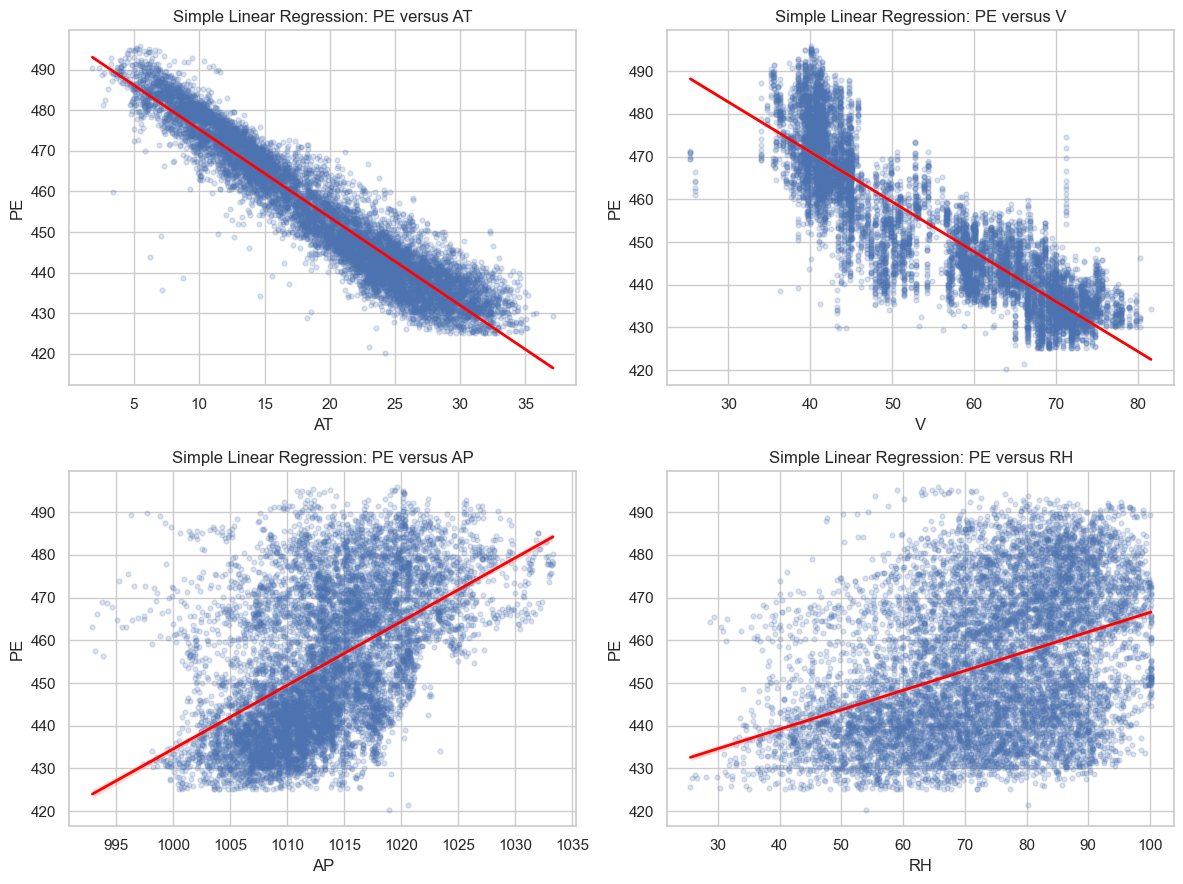

In [14]:
# one regression plot for each predictor
fig, axes = plt.subplots(2, 2,figsize=(12, 9))

for predictor, ax in zip(predictors, axes.flatten()):
    sns.regplot(data=data, x=predictor, y="PE", scatter_kws={"alpha": 0.20, "s": 12}, line_kws={"color": "red", "linewidth": 2}, ax=ax)
    ax.set_title(f"Simple Linear Regression: PE versus {predictor}")
    ax.set_xlabel(predictor)
    ax.set_ylabel("PE")

plt.tight_layout()
plt.show()

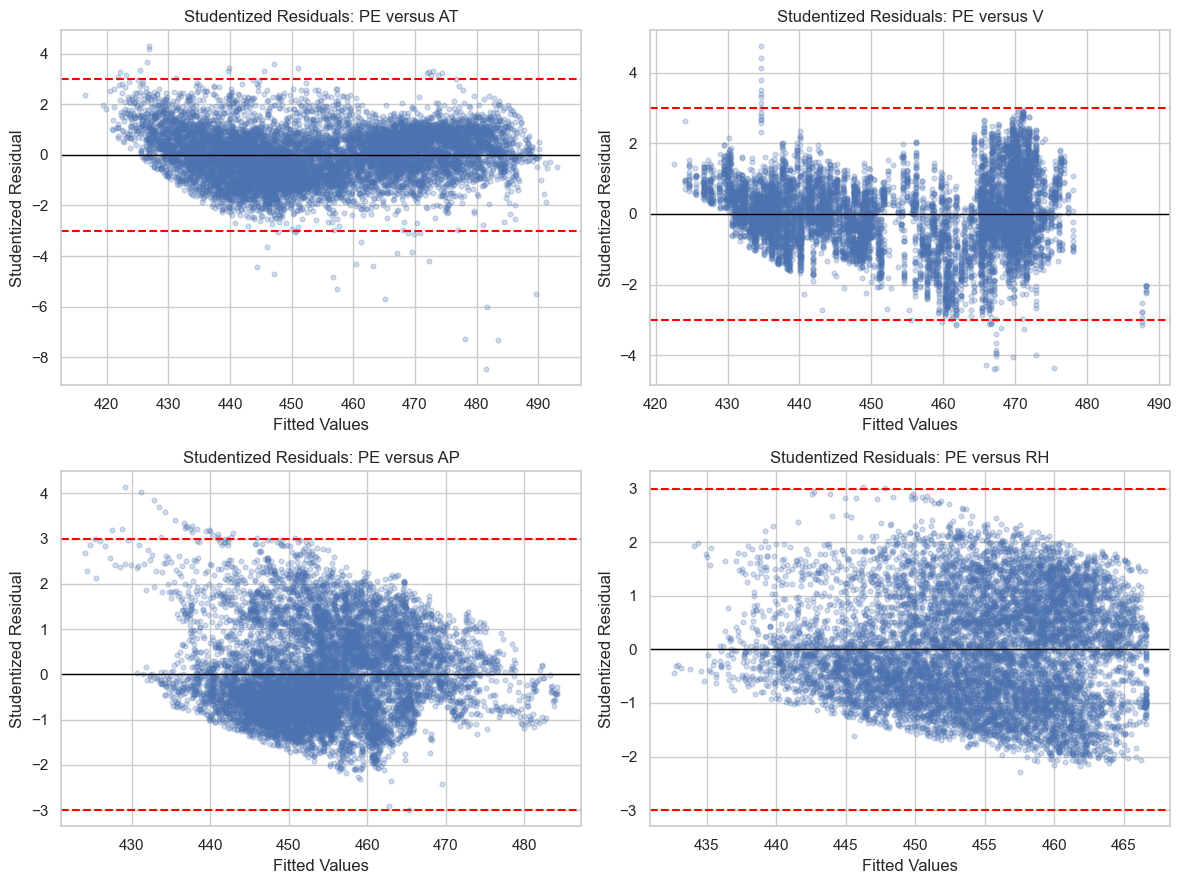

In [15]:
# residual plots for possible outliers
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for predictor, ax in zip(predictors, axes.flatten()):
    # regression for current model
    influence = simple_models[predictor].get_influence()
    studentized_residuals = (influence.resid_studentized_internal) # studentized residuals

    # residuals against fitted values
    ax.scatter(simple_models[predictor].fittedvalues, studentized_residuals, alpha=0.25, s=12)
    ax.axhline(0, color="black", linewidth=1) #reference lines
    ax.axhline(3, color="red", linestyle="--", label="Potential outlier boundary")
    ax.axhline(-3, color="red", linestyle="--")

    ax.set_title(f"Studentized Residuals: PE versus {predictor}")
    ax.set_xlabel("Fitted Values")
    ax.set_ylabel("Studentized Residual")

plt.tight_layout()
plt.show()

All four predictors have p-values less than 0.05, so each predictor has a statistically significant association with PE when considered in a separate simple linear regression model. The extremely small p-values are reasonable because the dataset contains 9,568 observations. However, statistical significance by iteslf doesn't show the strength or practical importance of a relationship. AT has the strongest individual linear relationship with PE, with an R-squared value of approximately 0.899. Its coefficient is ~ -2.171, meaning that a one-unit increase in AT is associated with an estimated 2.171-unit decrease in PE. V also has a relatively strong negative relationship with PE, with an R-squared value of ~0.757 and a coefficient of ~ -1.168. AP and RH have positive coefficients, but their R-squared values are much smaller. AP has an R-squared value of ~ 0.269, while RH has an R-squared value of ~ 0.152. This suggests that AP and RH explain much less of the variation in PE when used by themselves. The scatterplots and residual plots show that some of the relationships aren't perfectly linear. In particular, the residuals for AT, V, and AP have visible structure rather than appearing randomly distributed around zero. Several observations have studentized residuals outside the range from -3 to 3, specifically in the AT, V, and AP models. These observations could be potential outliers, but they are not clearly data-entry errors and could represent valid power-plant operating conditions. So, I kept all observations for the remaining analysis.

### (d) Multiple Regression

In [19]:
X_multiple = data[["AT", "V", "AP", "RH"]] # select all predictors
X_multiple = sm.add_constant(X_multiple) # Add an intercept to the model

# fit the multiple linear regression model
multiple_model = sm.OLS(data["PE"], X_multiple).fit()

# display the complete regression summary
print(multiple_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:16:43   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

In [20]:
# create table of coefficients and p-values
multiple_results = pd.DataFrame({
    "Coefficient": multiple_model.params,
    "P-value": multiple_model.pvalues
})

multiple_results.round(5)

,Coefficient,P-value
const,454.60927,0.0
AT,-1.97751,0.0
V,-0.23392,0.0
AP,0.06208,0.0
RH,-0.15805,0.0


The multiple linear regression model has an R-squared value of ~ 0.929, meaning that AT, V, AP, and RH together explain approximately 92.9% of the observed variation in PE. All four of the predictors have p-values less than 0.05. Therefore, I reject the null hypothesis \(H_0:\beta_j=0\) for AT, V, AP, and RH. Each predictor has a statistically significant association with PE after controlling for the other predictors.

Holding the other predictors constant, a one-unit increase in AT is associated with an estimated 1.978-unit decrease in PE; a one-unit increase in V is associated with an estimated 0.234-unit decrease in PE; a one-unit increase in AP is associated with an estimated 0.062-unit increase in PE; and a one-unit increase in RH is associated with an estimated 0.158-unit decrease in PE.

The sign of the RH coefficient is different from its sign in the simple regression model. This shows that the relationship between RH and PE changes after controlling for AT, V, and AP, most likely because the predictors are correlated with one another.

### (e) 1c Compare to 1d

In [22]:
# coefficient from each simple regression model
simple_coefficients = pd.Series({
    predictor: simple_models[
        predictor
    ].params[predictor]
    for predictor in predictors
})

#corresponding coefficients from the multiple regression model
multiple_coefficients = multiple_model.params[predictors]

# comparison table
coefficient_comparison = pd.DataFrame({"Simple Regression Coefficient": simple_coefficients, "Multiple Regression Coefficient": multiple_coefficients})
coefficient_comparison.round(5)

,Simple Regression Coefficient,Multiple Regression Coefficient
AT,-2.17132,-1.97751
V,-1.16814,-0.23392
AP,1.48987,0.06208
RH,0.45565,-0.15805


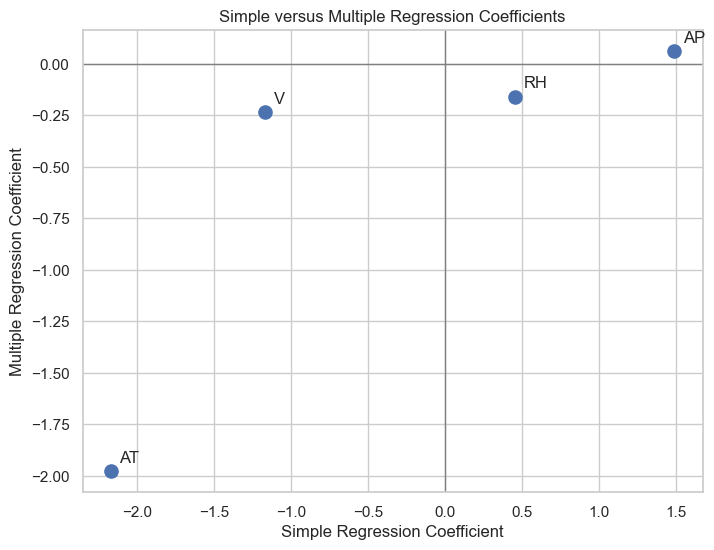

In [23]:
#simple-reg coefficients vs multiple-regression coeffs
plt.figure(figsize=(8, 6))
plt.scatter(simple_coefficients, multiple_coefficients, s=90)

# each pt with predictor name
for predictor in predictors:
    plt.annotate(
        predictor,
        (
            simple_coefficients[predictor],
            multiple_coefficients[predictor]
        ),
        xytext=(6, 6),
        textcoords="offset points"
    )

# ref lines at 0
plt.axhline(0, color="gray", linewidth=1)
plt.axvline(0, color="gray", linewidth=1)
plt.xlabel("Simple Regression Coefficient")
plt.ylabel("Multiple Regression Coefficient")
plt.title("Simple versus Multiple Regression Coefficients")

plt.grid(True)
plt.show()

The coefficients from the simple and multiple regression models differ because the simple regressions take into account each predictor individually, while the multiple regression estimates each predictor's association with PE while holding the other predictors constant. The AT coefficient changes relatively little, from about -2.171 in the simple regression to -1.978 in the multiple regression. This shows that AT has a strong negative association with PE even after controlling for the other variables. The magnitude of the V coefficient decreases substantially, from about -1.168 to -0.234. Similarly, the AP coefficient decreases from approximately 1.490 to 0.062. This shows that some of the associations seen in the simple regressions were related to correlations between V, AP, and the other predictors. The most noticeable change happens for RH. Its coefficient changes from approximately 0.456 in the simple regression to -0.158 in the multiple regression. So, RH has a positive association with PE when considered alone, but a negative association after controlling for AT, V, and AP.

Overall, the differences show that examining predictors individually can produce different conclusions from examining them together, particularly when the predictors are correlated.

### (f) Nonlinear Association

In [25]:
centered_data = data.copy() # centered versions of the predictors for numerical stability

for predictor in predictors:
    centered_data[f"{predictor}_centered"] = (data[predictor] - data[predictor].mean())
    
nonlinear_models = {} #fitted cubic models
nonlinear_results = [] #summary of the nonlinear-term results

#cubic model for each centered predictor
for predictor in predictors:
    centered_predictor = f"{predictor}_centered"

    formula = (
        f"PE ~ {centered_predictor} "
        f"+ I({centered_predictor} ** 2) "
        f"+ I({centered_predictor} ** 3)"
    )

    model = smf.ols(formula=formula, data=centered_data).fit()
    nonlinear_models[predictor] = model

    nonlinear_results.append({
        "Predictor": predictor,
        "Linear p-value":
            model.pvalues[centered_predictor],
        "Quadratic p-value":
            model.pvalues[
                f"I({centered_predictor} ** 2)"
            ],
        "Cubic p-value":
            model.pvalues[
                f"I({centered_predictor} ** 3)"
            ],
        "R-squared":
            model.rsquared
    })

nonlinear_results_table = pd.DataFrame(nonlinear_results)
nonlinear_results_table

,Predictor,Linear p-value,Quadratic p-value,Cubic p-value,R-squared
0,AT,0.000000e+00,3.311808e-231,3.652185e-110,0.911883
1,V,0.000000e+00,8.977010e-131,1.373489e-02,0.775022
2,AP,0.000000e+00,2.192722e-46,2.123338e-67,0.297543
3,RH,9.648727e-152,1.013949e-01,1.440279e-05,0.153743


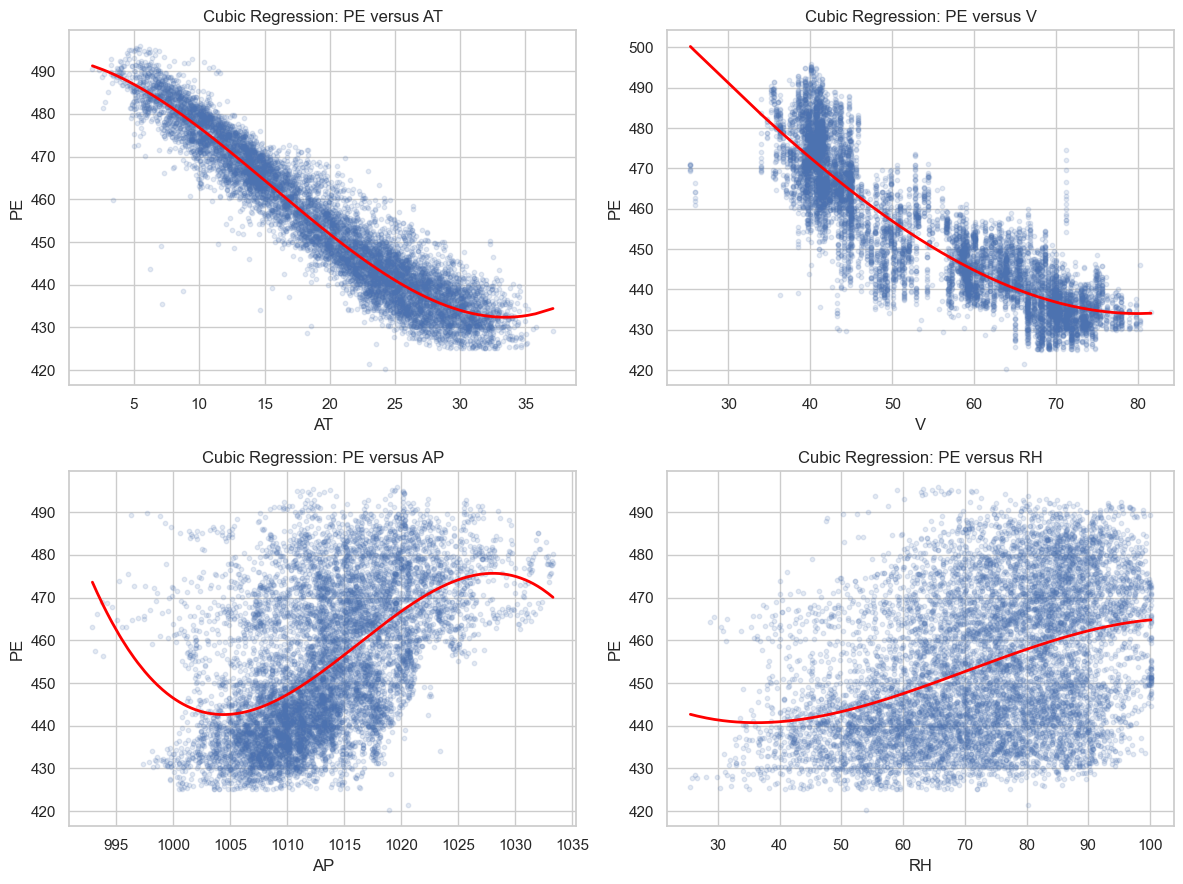

In [26]:
# fitted cubic-regression plots for all predictors
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for predictor, ax in zip(predictors, axes.flatten()):
    sorted_data = centered_data.sort_values(predictor) # sort centered data by original predictor

    # gen predictions using the corresponding cubic model
    predictions = nonlinear_models[predictor].predict(sorted_data)
    ax.scatter(data[predictor], data["PE"], alpha=0.15, s=10) # original observations

    # fitted cubic curve
    ax.plot(sorted_data[predictor], predictions, color="red", linewidth=2)
    ax.set_title(f"Cubic Regression: PE versus {predictor}")
    ax.set_xlabel(predictor)
    ax.set_ylabel("PE")

plt.tight_layout()
plt.show()

There is evidence of nonlinear association between each predictor and PE. For AT, both the quadratic and cubic terms have p-values less than 0.05. The fitted curve shows a strong negative relationship that becomes flatter at higher temperatures, confirming that the relationship isn't perfectly linear. For V, both the quadratic and cubic terms are statistically significant. The fitted curve shows that PE decreases rapidly at smaller values of V and then decreases more gradually as V becomes larger. For AP, both the quadratic and cubic terms are statistically significant. The fitted curve changes direction across the range observed, showing that the association between AP and PE is nonlinear. However, the relatively low R-squared value indicates that AP alone still explains a limited amount of the variation in PE. For RH, the quadratic term is not statistically significant at the 0.05 level because its p-value is about 0.101. However, the cubic term is statistically significant, so there is still evidence of a nonlinear relationship between RH and PE. The fitted curve shows a weak relationship that changes gradually across the observed range.

Overall, the polynomial models provide evidence of nonlinear association for all four predictors. The nonlinear patterns are especially visible for AT, V, and AP.

### (g) Interactions of Predictors

In [27]:
# model containing all predictors and pairwise interactions
interaction_formula = (
    "PE ~ AT + V + AP + RH "
    "+ AT:V + AT:AP + AT:RH "
    "+ V:AP + V:RH + AP:RH"
)

#full interaction model
interaction_model = smf.ols(formula=interaction_formula,data=data).fit()
print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:46:47   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

In [28]:
#all pairwise interaction terms
interaction_terms = [
    "AT:V",
    "AT:AP",
    "AT:RH",
    "V:AP",
    "V:RH",
    "AP:RH"
]

# table w the interaction coefficients and p-values
interaction_results = pd.DataFrame({
    "Coefficient": interaction_model.params[interaction_terms],
    "P-value": interaction_model.pvalues[interaction_terms]
})
interaction_results

,Coefficient,P-value
AT:V,0.020971,3.333358e-117
AT:AP,0.001759,4.520509e-01
AT:RH,-0.005230,1.216944e-10
V:AP,0.006812,2.877026e-07
V:RH,0.000839,8.619366e-02
AP:RH,-0.001612,3.360557e-02


The full interaction model has an R-squared value of about 0.936, which is slightly higher than the R-squared value of approximately 0.929 from the additive multiple linear regression model. Using a significance level of 0.05, the following interaction terms are statistically significant: AT × V, with a p-value < 0.05; AT × RH, with a p-value < 0.05; V × AP, with a p-value < 0.05; and AP × RH, with a p-value < 0.05

The AT × AP isn't statistically significant because its p-value is ~ 0.452. The V × RH also isn't statistically significant because its p-value is approximately 0.086. These results show that the association between some predictors and PE depends on the values of other predictors. In particular, the effects involving AT and V seem to contain important interactions.

Although the main effect of AT has a p-value slightly above 0.05 in this interaction model, it should not be removed while statistically significant interaction terms involving AT remain in the model.

### (h) Improvement

In [29]:
# random divide data into 70 train and 30 test
train_data, test_data = train_test_split(data, test_size=0.30, random_state=552)
print("Training set shape:", train_data.shape)
print("Test set shape:", test_data.shape)

Training set shape: (6697, 5)
Test set shape: (2871, 5)


In [30]:
#linear regression model using all four predictors
baseline_formula = ("PE ~ AT + V + AP + RH")
baseline_model = smf.ols(formula=baseline_formula, data=train_data).fit()

#predictions for both datasets
baseline_train_predictions = (baseline_model.predict(train_data))
baseline_test_predictions = (baseline_model.predict(test_data))

# train and test mse
baseline_train_mse = mean_squared_error(train_data["PE"], baseline_train_predictions)
baseline_test_mse = mean_squared_error(test_data["PE"], baseline_test_predictions)

print("Baseline linear-model training MSE:", baseline_train_mse)
print("Baseline linear-model test MSE:", baseline_test_mse)

Baseline linear-model training MSE: 20.354696873410806
Baseline linear-model test MSE: 21.74139498382111


In [31]:
training_means = train_data[predictors].mean() #predictor means using only the training data

# copies for the expanded regression model
train_model_data = train_data.copy()
test_model_data = test_data.copy()

#center both datasets using the training-set means
for predictor in predictors:
    train_model_data[f"{predictor}_centered"] = (train_data[predictor] - training_means[predictor])
    test_model_data[f"{predictor}_centered"] = (test_data[predictor] - training_means[predictor])

In [32]:
full_formula = (
    "PE ~ AT_centered + V_centered "
    "+ AP_centered + RH_centered "
    "+ I(AT_centered ** 2) "
    "+ I(V_centered ** 2) "
    "+ I(AP_centered ** 2) "
    "+ I(RH_centered ** 2) "
    "+ AT_centered:V_centered "
    "+ AT_centered:AP_centered "
    "+ AT_centered:RH_centered "
    "+ V_centered:AP_centered "
    "+ V_centered:RH_centered "
    "+ AP_centered:RH_centered"
) # full model with all main effects, quadratic terms, and pairwise interactions

#fit full model w/ only the training data
full_model = smf.ols(formula=full_formula, data=train_model_data).fit()
print(full_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.939
Model:                            OLS   Adj. R-squared:                  0.939
Method:                 Least Squares   F-statistic:                     7388.
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:54:20   Log-Likelihood:                -19124.
No. Observations:                6697   AIC:                         3.828e+04
Df Residuals:                    6682   BIC:                         3.838e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [33]:
full_model.pvalues.sort_values(ascending=False) #p-values from largest to smallest

AT_centered:AP_centered     4.923300e-01
V_centered:RH_centered      4.872565e-01
I(V_centered ** 2)          8.221808e-02
V_centered:AP_centered      4.370332e-02
AT_centered:RH_centered     4.638340e-03
AP_centered:RH_centered     9.755895e-04
AT_centered:V_centered      9.905368e-05
I(AT_centered ** 2)         4.845607e-07
I(AP_centered ** 2)         1.771767e-08
I(RH_centered ** 2)         2.338803e-09
AP_centered                 4.120987e-28
RH_centered                1.716718e-121
V_centered                 2.287325e-220
Intercept                   0.000000e+00
AT_centered                 0.000000e+00
dtype: float64

In [34]:
#removing the three insignificant higher-order terms: AT:AP, V:RH, and V squared
reduced_formula = (
    "PE ~ AT_centered + V_centered "
    "+ AP_centered + RH_centered "
    "+ I(AT_centered ** 2) "
    "+ I(AP_centered ** 2) "
    "+ I(RH_centered ** 2) "
    "+ AT_centered:V_centered "
    "+ AT_centered:RH_centered "
    "+ V_centered:AP_centered "
    "+ AP_centered:RH_centered"
)

# fitting the reduced model using training data
reduced_model = smf.ols(formula=reduced_formula, data=train_model_data).fit()
print(reduced_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.939
Model:                            OLS   Adj. R-squared:                  0.939
Method:                 Least Squares   F-statistic:                     9401.
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:55:52   Log-Likelihood:                -19126.
No. Observations:                6697   AIC:                         3.828e+04
Df Residuals:                    6685   BIC:                         3.836e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [35]:
#p-vals after refitting the reduced model
reduced_model.pvalues.sort_values(ascending=False)

V_centered:AP_centered      9.526958e-05
AT_centered:RH_centered     1.850126e-06
AP_centered:RH_centered     1.666903e-06
AT_centered:V_centered      3.547997e-08
I(RH_centered ** 2)         5.941538e-11
I(AP_centered ** 2)         4.622494e-12
I(AT_centered ** 2)         8.212307e-20
AP_centered                 1.381649e-30
RH_centered                6.947146e-123
V_centered                 1.159907e-230
Intercept                   0.000000e+00
AT_centered                 0.000000e+00
dtype: float64

In [36]:
reduced_train_predictions = (reduced_model.predict(train_model_data)) #predictions from the reduced model
reduced_test_predictions = (reduced_model.predict(test_model_data))

# Calculate training and test MSE
reduced_train_mse = mean_squared_error(train_model_data["PE"], reduced_train_predictions)
reduced_test_mse = mean_squared_error(test_model_data["PE"], reduced_test_predictions)
print("Reduced-model training MSE:", reduced_train_mse)
print("Reduced-model test MSE:", reduced_test_mse)

Reduced-model training MSE: 17.70865466741434
Reduced-model test MSE: 19.08288542668681


In [37]:
# compare the baseline and reduced reg mods
regression_comparison = pd.DataFrame({
    "Model": ["All Predictors Linear", "Reduced Interaction/Quadratic"],
    "Training MSE": [baseline_train_mse, reduced_train_mse],
    "Test MSE": [baseline_test_mse, reduced_test_mse]
})

regression_comparison.round(4)

,Model,Training MSE,Test MSE
0,All Predictors Linear,20.3547,21.7414
1,Reduced Interaction/Quadratic,17.7087,19.0829


I randomly divided the dataset into a 70% training set and a 30% test set using a fixed random state of 552. The same split will also be used for the KNN regression so that the models can be compared fairly. The baseline linear model containing AT, V, AP, and RH had a training MSE of approximately 20.3547 and a test MSE of approximately 21.7414.
Then, I fitted a full model containing all four main effects, all four quadratic terms, and all six pairwise interaction terms. Based on the training-set p-values, I removed these insignificant higher-order terms: AT × AP, V × RH, and the quadratic V term. I kept all four main effects to maintain the hierarchical structure of the model. I also kept the main effects associated with every remaining quadratic and interaction term. The reduced interaction/quadratic model had a training MSE of ~17.7087 and a test MSE of ~19.0829. Both values are lower than the corresponding MSEs from the baseline linear model. In conclusion, including selected nonlinear and interaction terms improves the model's predictive performance.

### (i) KNN

In [38]:
feature_columns = ["AT", "V", "AP", "RH"] # predictor cols used for knn regression
# same training and test observations as h
X_train = train_data[feature_columns]
y_train = train_data["PE"]

X_test = test_data[feature_columns]
y_test = test_data["PE"]

# calc every k from 1 through 100
k_values = list(range(1, 101))
print("Training predictor shape:", X_train.shape)
print("Test predictor shape:", X_test.shape)

Training predictor shape: (6697, 4)
Test predictor shape: (2871, 4)


In [40]:
# train and test mse for raw features
raw_train_mse = []
raw_test_mse = []

# eval knn regression for k = 1 through 100
for k in k_values:
    raw_knn_model = KNeighborsRegressor(n_neighbors=k)

    #fit using the raw training features
    raw_knn_model.fit(X_train, y_train)

    # gen predictions
    raw_train_predictions = (raw_knn_model.predict(X_train))
    raw_test_predictions = (raw_knn_model.predict(X_test))
    raw_train_mse.append(mean_squared_error(y_train, raw_train_predictions)) #mse vals
    raw_test_mse.append(mean_squared_error(y_test, raw_test_predictions))

In [41]:
# k value with the smallest raw ft test mse
best_raw_index = np.argmin(raw_test_mse)
best_raw_k = k_values[best_raw_index]
best_raw_train_mse = raw_train_mse[best_raw_index]
best_raw_test_mse = raw_test_mse[best_raw_index]

print("Best raw-feature k:", best_raw_k)
print("Training MSE at the best raw-feature k:", best_raw_train_mse)
print("Test MSE at the best raw-feature k:", best_raw_test_mse)

Best raw-feature k: 5
Training MSE at the best raw-feature k: 10.117292645064952
Test MSE at the best raw-feature k: 17.222491062347604


In [42]:
# standardization object
scaler = StandardScaler()

# learn means and std dev from training data and transform the training predictors
X_train_scaled = scaler.fit_transform(X_train)
# trasnform the test predictors using the training set params
X_test_scaled = scaler.transform(X_test)

In [43]:
normalized_train_mse = []
normalized_test_mse = []

# eval knn reg for k = 1 through 100
for k in k_values:
    normalized_knn_model = KNeighborsRegressor(n_neighbors=k)

    # fit model using normalized training features
    normalized_knn_model.fit(X_train_scaled, y_train)

    #predictions
    normalized_train_predictions = (normalized_knn_model.predict(X_train_scaled))
    normalized_test_predictions = (normalized_knn_model.predict(X_test_scaled))

    #mse values
    normalized_train_mse.append(mean_squared_error(y_train, normalized_train_predictions))
    normalized_test_mse.append(mean_squared_error(y_test, normalized_test_predictions))

In [44]:
best_normalized_index = np.argmin(normalized_test_mse) #k with the smallest normalized feature test mse

best_normalized_k = k_values[best_normalized_index]
best_normalized_train_mse = (normalized_train_mse[best_normalized_index])

best_normalized_test_mse = (normalized_test_mse[best_normalized_index])
print("Best normalized feature k:", best_normalized_k)
print("Training MSE at the best normalized feature k:", best_normalized_train_mse)
print("Test MSE at the best normalized feature k:", best_normalized_test_mse)

Best normalized feature k: 6
Training MSE at the best normalized feature k: 10.077763205747184
Test MSE at the best normalized feature k: 16.00172432272921


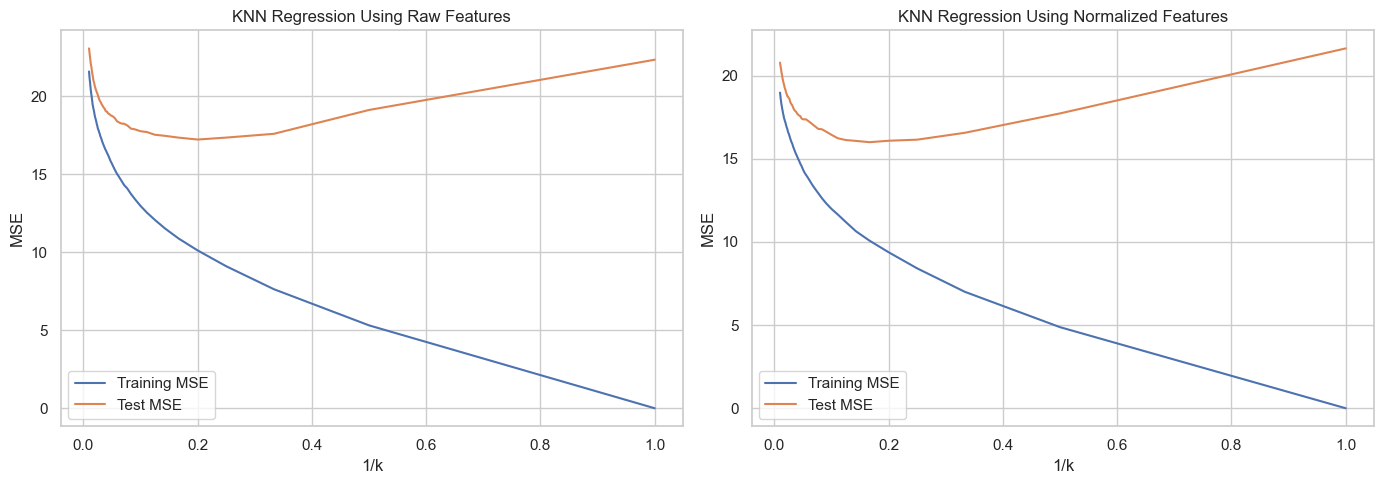

In [45]:
# calc 1/k for the horizontal axis
inverse_k = [
    1 / k
    for k in k_values
]

# diff plots for raw and normalized predictors
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# raw ft KNN errors
axes[0].plot(inverse_k, raw_train_mse, label="Training MSE")
axes[0].plot(inverse_k, raw_test_mse, label="Test MSE")
axes[0].set_title("KNN Regression Using Raw Features")
axes[0].set_xlabel("1/k")
axes[0].set_ylabel("MSE")
axes[0].legend()
axes[0].grid(True)

# Normalized-feature KNN errors
axes[1].plot(inverse_k, normalized_train_mse, label="Training MSE")
axes[1].plot(inverse_k, normalized_test_mse, label="Test MSE")
axes[1].set_title("KNN Regression Using Normalized Features")
axes[1].set_xlabel("1/k")
axes[1].set_ylabel("MSE")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [46]:
# summ the best raw and normalized knn results
knn_summary = pd.DataFrame({
    "Feature Type": [
        "Raw",
        "Normalized"
    ],
    "Best k": [best_raw_k, best_normalized_k],
    "Training MSE": [best_raw_train_mse, best_normalized_train_mse],
    "Test MSE": [best_raw_test_mse, best_normalized_test_mse]
})
knn_summary.round(4)

,Feature Type,Best k,Training MSE,Test MSE
0,Raw,5,10.1173,17.2225
1,Normalized,6,10.0778,16.0017


For KNN regression using the raw predictors, the lowest test MSE was ~17.2225 at \(k=5\). The corresponding training MSE was ~10.1173.
After normalizing the predictors, the lowest test MSE reduced to approximately 16.0017 at \(k=6\). The corresponding training MSE was ~10.0778. The plots show the bias-variance tradeoff. At \(k=1\), the training MSE is zero because each training observation is its own nearest neighbor. However, the test MSE is relatively high, showing overfitting. As \(k\) increases, the model becomes smoother. The test MSE initially decreases, reaches a minimum, and then increases again for larger values of \(k\), showing underfitting. The normalized-feature KNN model performs better than the raw-feature model. KNN depends on distances between observations, so predictors with larger numerical scales can otherwise have too much influence. Standardizing the predictors gives each variable a comparable role in the distance calculation.

### (j ) Compare KNN and Linear

In [47]:
# compare all regression approaches using test mse
final_model_comparison = pd.DataFrame({
    "Model": [
        "Baseline Linear Regression",
        "Reduced Interaction/Quadratic Regression",
        "Raw-feature KNN",
        "Normalized-feature KNN"
    ],
    "Test MSE": [baseline_test_mse, reduced_test_mse, best_raw_test_mse, best_normalized_test_mse]
})

# sort models from smallest to largest test mse
final_model_comparison = (final_model_comparison.sort_values("Test MSE").reset_index(drop=True))
final_model_comparison.round(4)

,Model,Test MSE
0,Normalized-feature KNN,16.0017
1,Raw-feature KNN,17.2225
2,Reduced Interaction/Quadratic Regression,19.0829
3,Baseline Linear Regression,21.7414


The normalized-feature KNN model got the smallest test MSE, at ~ 16.0017 at \(k=6\). It provided the best predictive performance among the models considered. The raw-feature KNN model had the next-lowest test MSE, approximately 17.2225, with \(k=5\). Normalization improved KNN performance because KNN calculates distances between observations, and standardization prevents variables with larger numerical scales from dominating those distances. Among the linear-regression approaches, the reduced interaction/quadratic model performed better than the baseline model. Its test MSE was approximately 19.0829, compared with approximately 21.7414 for the baseline linear model. This shows that nonlinear and interaction terms capture meaningful structure that the purely additive linear model misses. Overall, KNN regression captured local and nonlinear relationships more effectively than the fitted linear-regression models. The normalized KNN model was the best model in this analysis based on test MSE. However, the regression models stay easier to interpret because their coefficients describe the estimated relationships between the predictors and PE.

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

A flexible statistical learning method would perform better than an inflexible method in this situation. Because the sample size is very large compared to the number of predictors, there is enough information to estimate a more complex relationship without that much of a risk of overfitting, so a flexible method may capture patterns that an inflexible method would miss.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

A flexible statistical learning method would generally perform worse than an inflexible method in this situation. When there are many predictors but few observations, a flexible model could easily fit random noise in the training data and this outputs high variance and poor performance on new observations.

### (c) The relationship between the predictors and response is highly non-linear.

A flexible statistical learning method would generally perform better than an inflexible method in this situation since a flexible method can adapt to a highly nonlinear relationship, while an inflexible method may impose an overly simple form and underfit the data.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

A flexible statistical learning method would generally perform worse than an inflexible method in this situation because when the error variance is extremely high, a lot of the variation in the response is random noise. A flexible model may fit that noise rather than the underlying relationship, which results in high variance and worse test performance.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

### (b) What is our prediction with K = 1? Why?

### (c) What is our prediction with K = 3? Why?

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?